# Literary Emotion & Environment Analysis — Project Gutenberg → Colab

This notebook starts **only from a Project Gutenberg plain-text book**. It does not require a ZIP, pre-generated CSV, or external book file.

### Pipeline
**Project Gutenberg → clean text → chapters → paragraphs → sentences → ModernBERT-GoEmotions → paragraph emotion flow → environmental/narrative context → plots + tables**

### What is shown in Colab
- Sentence-level emotion probabilities (28 GoEmotions labels)
- Paragraph-level emotion probabilities
- Top 15 non-neutral emotion flow
- Dominant non-neutral emotion by paragraph
- Environmental/narrative context by paragraph
- Movement/location context
- Research summary tables
- Plots only; no ZIP generation

**Research note:** model probabilities are computational predictions, not direct measurements of an author's or character's true psychological state. Context categories are transparent lexical/context cues, not claims of full literary understanding.

## Important execution order
Run cells **top to bottom**.

The first setup cell only checks the environment and removes an incompatible `torchvision` package if necessary. If it reports that a restart is required, use **Runtime → Restart session**, then run the notebook again from the first cell.

The model-loading cell has a hard safety check: sentence inference will not run unless `model` and `tokenizer` were successfully created.

In [1]:
# ============================================================
# 1. ENVIRONMENT CHECK + TORCHVISION CONFLICT FIX
# ============================================================

import sys
import subprocess
import importlib.util
import os

print("Python:", sys.version)

# ModernBERT is a text model. An incompatible torchvision build can
# break Transformers import with: operator torchvision::nms does not exist.
# We do not need torchvision for this notebook.

tv = importlib.util.find_spec("torchvision")
if tv is not None:
    print("torchvision detected. Removing it because this text-only notebook does not need it...")
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"],
        check=False
    )
    print("torchvision removal requested.")
    print("If Transformers still reports a torchvision error, restart the Colab session once, then run all cells again.")
else:
    print("torchvision is not installed — good for this text-only pipeline.")

# Core packages. These are lightweight relative to the model and should
# already exist in Colab; install only missing packages.
required = {
    "transformers": "transformers==4.57.3",
    "accelerate": "accelerate>=1.2.1",
    "sentencepiece": "sentencepiece>=0.2.0",
    "requests": "requests>=2.32.0",
    "tqdm": "tqdm>=4.67.0",
    "spacy": "spacy>=3.8.0",
}

missing = [spec for module, spec in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required Python packages are already available.")

print("Environment setup complete.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
torchvision detected. Removing it because this text-only notebook does not need it...
torchvision removal requested.
If Transformers still reports a torchvision error, restart the Colab session once, then run all cells again.
Required Python packages are already available.
Environment setup complete.


In [2]:
# ============================================================
# 2. IMPORTS + ENVIRONMENT VERIFICATION
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from tqdm.auto import tqdm

import torch

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Test the scientific stack before importing Transformers.
test = np.array([1.0, 2.0, 3.0])
print("NumPy test mean:", test.mean())

# If torchvision is still importable after the previous cell, give a clear
# instruction instead of allowing a confusing ModernBERT traceback later.
if importlib.util.find_spec("torchvision") is not None:
    print("WARNING: torchvision is still present. If model loading fails with torchvision::nms, restart the Colab session once.")
else:
    print("✓ torchvision is absent; safe for the text-only ModernBERT pipeline.")

NumPy: 2.1.3
Pandas: 2.2.3
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
NumPy test mean: 2.0
✓ torchvision is absent; safe for the text-only ModernBERT pipeline.


## 3. Select the Project Gutenberg book

Change only `GUTENBERG_ID` to analyze another public-domain Gutenberg book.

In [3]:
# ============================================================
# 3. PROJECT GUTENBERG BOOK
# ============================================================

GUTENBERG_ID = "11"  # Alice's Adventures in Wonderland

GUTENBERG_TEXT_URL = (
    f"https://www.gutenberg.org/cache/epub/{GUTENBERG_ID}/pg{GUTENBERG_ID}.txt"
)

print("Project Gutenberg ID:", GUTENBERG_ID)
print("Source:", GUTENBERG_TEXT_URL)


Project Gutenberg ID: 11
Source: https://www.gutenberg.org/cache/epub/11/pg11.txt


In [4]:
# ============================================================
# 4. DOWNLOAD FROM PROJECT GUTENBERG ONLY
# ============================================================

headers = {"User-Agent": "Literary-NLP-Research/1.0"}

response = requests.get(
    GUTENBERG_TEXT_URL,
    headers=headers,
    timeout=60
)
response.raise_for_status()

raw_text = response.text

if len(raw_text) < 1000:
    raise RuntimeError("Downloaded Gutenberg text is unexpectedly short.")

print("Downloaded characters:", len(raw_text))
print("✓ Book downloaded directly from Project Gutenberg.")

Downloaded characters: 167712
✓ Book downloaded directly from Project Gutenberg.


In [5]:
# ============================================================
# 5. REMOVE GUTENBERG HEADER / FOOTER
# ============================================================

def clean_gutenberg_text(text):
    cleaned = text.replace("\r\n", "\n").replace("\r", "\n")

    start_patterns = [
        r"\*\*\* START OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        r"\*\*\* START OF PROJECT GUTENBERG.*?\*\*\*"
    ]
    end_patterns = [
        r"\*\*\* END OF (?:THE|THIS) PROJECT GUTENBERG EBOOK.*",
        r"\*\*\* END OF PROJECT GUTENBERG.*"
    ]

    for pattern in start_patterns:
        m = re.search(pattern, cleaned, flags=re.I | re.S)
        if m:
            cleaned = cleaned[m.end():]
            break

    for pattern in end_patterns:
        m = re.search(pattern, cleaned, flags=re.I | re.S)
        if m:
            cleaned = cleaned[:m.start()]
            break

    cleaned = re.sub(r"\n{4,}", "\n\n\n", cleaned)
    return cleaned.strip()

book_text = clean_gutenberg_text(raw_text)

print("Raw characters:", len(raw_text))
print("Cleaned characters:", len(book_text))
print("\nPreview:\n")
print(book_text[:1500])

Raw characters: 167712
Cleaned characters: 144573

Preview:

[Illustration]


Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence


CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considerin

In [6]:
# ============================================================
# 6. CHAPTER + PARAGRAPH SEGMENTATION
# ============================================================

chapter_pattern = re.compile(
    r"(?im)^\s*(chapter\s+(?:[ivxlcdm]+|\d+|[a-z]+)(?:\s*[:.\-].*)?)\s*$"
)

lines = book_text.splitlines()
chapter_starts = []

for i, line in enumerate(lines):
    if chapter_pattern.match(line.strip()):
        chapter_starts.append(i)

# Remove near-duplicate detections.
filtered = []
for idx in chapter_starts:
    if not filtered or idx - filtered[-1] > 2:
        filtered.append(idx)
chapter_starts = filtered

chapters = []
if chapter_starts:
    for j, start in enumerate(chapter_starts):
        end = chapter_starts[j + 1] if j + 1 < len(chapter_starts) else len(lines)
        heading = lines[start].strip()
        content = "\n".join(lines[start + 1:end]).strip()
        if content:
            chapters.append({
                "chapter_number": j + 1,
                "chapter_heading": heading,
                "text": content
            })
else:
    chapters = [{
        "chapter_number": 1,
        "chapter_heading": "Book",
        "text": book_text
    }]

paragraph_rows = []
global_paragraph = 0

for chapter in chapters:
    raw_paragraphs = re.split(r"\n\s*\n+", chapter["text"])
    paragraph_number = 0

    for p in raw_paragraphs:
        p = re.sub(r"\s+", " ", p).strip()
        if len(p) < 20:
            continue

        paragraph_number += 1
        global_paragraph += 1
        paragraph_rows.append({
            "book_id": GUTENBERG_ID,
            "chapter_number": chapter["chapter_number"],
            "chapter_heading": chapter["chapter_heading"],
            "paragraph_number": paragraph_number,
            "global_paragraph_number": global_paragraph,
            "paragraph_text": p,
            "book_progress": (global_paragraph - 1) / max(1, global_paragraph)
        })

paragraph_df = pd.DataFrame(paragraph_rows)

# Correct normalized position after total paragraph count is known.
paragraph_df["book_progress"] = (
    paragraph_df["global_paragraph_number"] - 1
) / max(1, len(paragraph_df) - 1)

print("Chapters:", len(chapters))
print("Paragraphs:", len(paragraph_df))
display(paragraph_df.head(10))

Chapters: 16
Paragraphs: 797


,book_id,chapter_number,chapter_heading,paragraph_number,global_paragraph_number,paragraph_text,book_progress
0,11,1,CHAPTER I. Down the Rabbit-Hole,1,1,CHAPTER II. The Pool of Tears CHAPTER III. A C...,0.000000
1,11,2,CHAPTER IV. The Rabbit Sends in a Little Bill,1,2,CHAPTER V. Advice from a Caterpillar CHAPTER V...,0.001256
2,11,3,CHAPTER VII. A Mad Tea-Party,1,3,CHAPTER VIII. The Queen’s Croquet-Ground CHAPT...,0.002513
3,11,4,CHAPTER X. The Lobster Quadrille,1,4,CHAPTER XI. Who Stole the Tarts? CHAPTER XII. ...,0.003769
4,11,5,CHAPTER I.,1,5,Down the Rabbit-Hole,0.005025
5,11,5,CHAPTER I.,2,6,Alice was beginning to get very tired of sitti...,0.006281
6,11,5,CHAPTER I.,3,7,So she was considering in her own mind (as wel...,0.007538
7,11,5,CHAPTER I.,4,8,There was nothing so _very_ remarkable in that...,0.008794
8,11,5,CHAPTER I.,5,9,"In another moment down went Alice after it, ne...",0.010050
9,11,5,CHAPTER I.,6,10,The rabbit-hole went straight on like a tunnel...,0.011307


In [7]:
# ============================================================
# 7. SENTENCE SEGMENTATION
# ============================================================

import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except Exception:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"])
    nlp = spacy.load("en_core_web_sm")

sentence_rows = []

for _, row in tqdm(
    paragraph_df.iterrows(),
    total=len(paragraph_df),
    desc="Segmenting sentences"
):
    doc = nlp(row["paragraph_text"])
    for sentence_number, sent in enumerate(doc.sents, start=1):
        text = sent.text.strip()
        if len(text) < 3:
            continue
        sentence_rows.append({
            "book_id": row["book_id"],
            "chapter_number": row["chapter_number"],
            "chapter_heading": row["chapter_heading"],
            "paragraph_number": row["paragraph_number"],
            "global_paragraph_number": row["global_paragraph_number"],
            "sentence_number": sentence_number,
            "sentence_text": text,
            "book_progress": row["book_progress"]
        })

sentence_df = pd.DataFrame(sentence_rows)

print("Sentences:", len(sentence_df))
display(sentence_df.head(10))

Segmenting sentences:   0%|          | 0/797 [00:00<?, ?it/s]

Sentences: 1524


,book_id,chapter_number,chapter_heading,paragraph_number,global_paragraph_number,sentence_number,sentence_text,book_progress
0,11,1,CHAPTER I. Down the Rabbit-Hole,1,1,1,CHAPTER II.,0.000000
1,11,1,CHAPTER I. Down the Rabbit-Hole,1,1,2,The Pool of Tears CHAPTER III.,0.000000
2,11,1,CHAPTER I. Down the Rabbit-Hole,1,1,3,A Caucus-Race and a Long Tale,0.000000
3,11,2,CHAPTER IV. The Rabbit Sends in a Little Bill,1,2,1,CHAPTER V. Advice from a Caterpillar CHAPTER VI.,0.001256
4,11,2,CHAPTER IV. The Rabbit Sends in a Little Bill,1,2,2,Pig and Pepper,0.001256
5,11,3,CHAPTER VII. A Mad Tea-Party,1,3,1,CHAPTER VIII.,0.002513
6,11,3,CHAPTER VII. A Mad Tea-Party,1,3,2,The Queen’s Croquet-Ground CHAPTER IX.,0.002513
7,11,3,CHAPTER VII. A Mad Tea-Party,1,3,3,The Mock Turtle’s Story,0.002513
8,11,4,CHAPTER X. The Lobster Quadrille,1,4,1,CHAPTER XI.,0.003769
9,11,4,CHAPTER X. The Lobster Quadrille,1,4,2,Who Stole the Tarts?,0.003769


## 8. Load ModernBERT-GoEmotions

Model selected for this project based on the preliminary model comparison:
`cirimus/modernbert-base-go-emotions`.

**Important:** GoEmotions is a multi-label emotion dataset. Therefore, the model outputs are converted with **sigmoid**, not softmax. Each of the 28 emotion probabilities is retained independently.

In [8]:
# ============================================================
# 8. LOAD MODERNBERT-GOEMOTIONS
# ============================================================

# Do not run sentence inference unless this cell completes successfully.
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "cirimus/modernbert-base-go-emotions"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Loading:", MODEL_NAME)

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
except Exception as exc:
    raise RuntimeError(
        "ModernBERT could not be loaded. If the traceback contains "
        "'torchvision::nms does not exist', restart the Colab session "
        "after Cell 1 and run all cells again."
    ) from exc

model = model.to(device)
model.eval()

num_labels = int(model.config.num_labels)
print("Model loaded successfully.")
print("Number of labels:", num_labels)

if num_labels != 28:
    raise RuntimeError(f"Expected 28 GoEmotions labels, found {num_labels}.")

print("✓ 28 GoEmotions labels confirmed.")

Device: cuda
Loading: cirimus/modernbert-base-go-emotions


config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/356 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Model loaded successfully.
Number of labels: 28
✓ 28 GoEmotions labels confirmed.


In [9]:
# ============================================================
# 9. GOEMOTIONS LABEL ORDER
# ============================================================

GO_EMOTIONS = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness", "surprise",
    "neutral"
]

if len(GO_EMOTIONS) != 28:
    raise RuntimeError("GO_EMOTIONS must contain exactly 28 labels.")

print("GoEmotions labels:", len(GO_EMOTIONS))
print(", ".join(GO_EMOTIONS))

GoEmotions labels: 28
admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise, neutral


In [10]:
# ============================================================
# 10. SENTENCE-LEVEL EMOTION PREDICTION
# ============================================================

if "model" not in globals() or "tokenizer" not in globals():
    raise RuntimeError("Model/tokenizer missing. Run Cell 8 successfully first.")
if "sentence_df" not in globals():
    raise RuntimeError("sentence_df missing. Run sentence segmentation first.")

BATCH_SIZE = 16 if device.type == "cuda" else 4
MAX_LENGTH = 512

emotion_arrays = []
texts = sentence_df["sentence_text"].astype(str).tolist()

for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="Emotion inference"):
    batch = texts[start:start + BATCH_SIZE]
    encoded = tokenizer(
        batch,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)
        # GoEmotions is multi-label: each emotion is independent.
        probabilities = torch.sigmoid(outputs.logits).cpu().numpy()

    emotion_arrays.append(probabilities)

sentence_probabilities = np.vstack(emotion_arrays)

if sentence_probabilities.shape[1] != 28:
    raise RuntimeError(
        f"Model returned {sentence_probabilities.shape[1]} outputs; expected 28."
    )

for i, emotion in enumerate(GO_EMOTIONS):
    sentence_df[f"emotion_{emotion}"] = sentence_probabilities[:, i]

print("Emotion inference completed.")
print("Sentence rows:", len(sentence_df))
print("Probability matrix:", sentence_probabilities.shape)

display(sentence_df[["sentence_id" if "sentence_id" in sentence_df.columns else "sentence_number", "sentence_text", "emotion_neutral"]].head(20))

Emotion inference:   0%|          | 0/96 [00:00<?, ?it/s]

Emotion inference completed.
Sentence rows: 1524
Probability matrix: (1524, 28)


,sentence_number,sentence_text,emotion_neutral
0,1,CHAPTER II.,0.964833
1,2,The Pool of Tears CHAPTER III.,0.967185
2,3,A Caucus-Race and a Long Tale,0.950246
3,1,CHAPTER V. Advice from a Caterpillar CHAPTER VI.,0.900369
4,2,Pig and Pepper,0.971833
5,1,CHAPTER VIII.,0.968215
6,2,The Queen’s Croquet-Ground CHAPTER IX.,0.966170
7,3,The Mock Turtle’s Story,0.948040
8,1,CHAPTER XI.,0.964947
9,2,Who Stole the Tarts?,0.424768


In [11]:
# ============================================================
# 11. AGGREGATE SENTENCE EMOTIONS → PARAGRAPHS
# ============================================================

emotion_cols = [f"emotion_{e}" for e in GO_EMOTIONS]
group_cols = [
    "book_id", "chapter_number", "chapter_heading",
    "paragraph_number", "global_paragraph_number", "book_progress"
]

paragraph_emotions = (
    sentence_df.groupby(group_cols)[emotion_cols]
    .mean()
    .reset_index()
)

paragraph_texts = (
    sentence_df.groupby(group_cols)["sentence_text"]
    .apply(lambda x: " ".join(x))
    .reset_index(name="paragraph_text")
)

paragraph_emotions = paragraph_emotions.merge(
    paragraph_texts, on=group_cols, how="left"
).sort_values("global_paragraph_number").reset_index(drop=True)

paragraph_emotions["neutral_probability"] = paragraph_emotions["emotion_neutral"]

print("Paragraphs with emotion probabilities:", len(paragraph_emotions))
display(paragraph_emotions[["global_paragraph_number", "chapter_number", "book_progress", "paragraph_text", "neutral_probability"]].head(20))

Paragraphs with emotion probabilities: 797


,global_paragraph_number,chapter_number,book_progress,paragraph_text,neutral_probability
0,1,1,0.000000,CHAPTER II. The Pool of Tears CHAPTER III. A C...,0.960755
1,2,2,0.001256,CHAPTER V. Advice from a Caterpillar CHAPTER V...,0.936101
2,3,3,0.002513,CHAPTER VIII. The Queen’s Croquet-Ground CHAPT...,0.960809
3,4,4,0.003769,CHAPTER XI. Who Stole the Tarts? CHAPTER XII. ...,0.833032
4,5,5,0.005025,Down the Rabbit-Hole,0.960479
5,6,5,0.006281,Alice was beginning to get very tired of sitti...,0.457283
6,7,5,0.007538,So she was considering in her own mind (as wel...,0.608482
7,8,5,0.008794,There was nothing so _very_ remarkable in that...,0.397057
8,9,5,0.010050,"In another moment down went Alice after it, ne...",0.795851
9,10,5,0.011307,The rabbit-hole went straight on like a tunnel...,0.776035



# FINAL RESEARCH VISUALIZATION — EMOTION + ENVIRONMENT

Only the main plots are included.

## Section 1 — Emotion
1. Full-book paragraph emotion flow, split into 6 parts.
2. Dominant emotion across all paragraphs.
3. Sentence-by-sentence emotion flow across 10 consecutive paragraphs.

## Section 2 — Environmental context
1. Full-book environmental topic flow, split into 6 parts.
2. Overall environmental topic presence.

The main emotion analysis uses the 15 strongest non-neutral GoEmotions labels.
`neutral` remains in the underlying model output but is not used in the main
emotion-flow visualization.

Environmental flow shows actual detected context topics; paragraphs with no
detected topic are left blank rather than plotted as a dominant category.


In [12]:

# ============================================================
# FINAL SETUP — 28 EMOTIONS + TOP 15 NON-NEUTRAL
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GO_EMOTIONS = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness",
    "surprise", "neutral"
]

NON_NEUTRAL = [e for e in GO_EMOTIONS if e != "neutral"]

paragraph_analysis = paragraph_emotions.copy()
paragraph_analysis = paragraph_analysis.sort_values(
    "global_paragraph_number"
).reset_index(drop=True)

emotion_strength = pd.DataFrame({
    "emotion": NON_NEUTRAL,
    "mean_probability": [
        paragraph_analysis[f"emotion_{e}"].mean()
        for e in NON_NEUTRAL
    ]
}).sort_values(
    "mean_probability",
    ascending=False
).reset_index(drop=True)

TOP_15_EMOTIONS = emotion_strength.head(15)["emotion"].tolist()
TOP_15_COLS = [f"emotion_{e}" for e in TOP_15_EMOTIONS]

paragraph_analysis["dominant_emotion"] = (
    paragraph_analysis[TOP_15_COLS]
    .idxmax(axis=1)
    .str.replace("emotion_", "", regex=False)
)

print("Number of emotion labels:", len(GO_EMOTIONS))
for i, label in enumerate(GO_EMOTIONS):
    print(f"{i:02d} : {label}")

print("\n15 emotions used in the main plots:")
print(", ".join(TOP_15_EMOTIONS))


Number of emotion labels: 28
00 : admiration
01 : amusement
02 : anger
03 : annoyance
04 : approval
05 : caring
06 : confusion
07 : curiosity
08 : desire
09 : disappointment
10 : disapproval
11 : disgust
12 : embarrassment
13 : excitement
14 : fear
15 : gratitude
16 : grief
17 : joy
18 : love
19 : nervousness
20 : optimism
21 : pride
22 : realization
23 : relief
24 : remorse
25 : sadness
26 : surprise
27 : neutral

15 emotions used in the main plots:
curiosity, annoyance, approval, confusion, disapproval, realization, anger, admiration, sadness, surprise, joy, fear, disappointment, caring, optimism


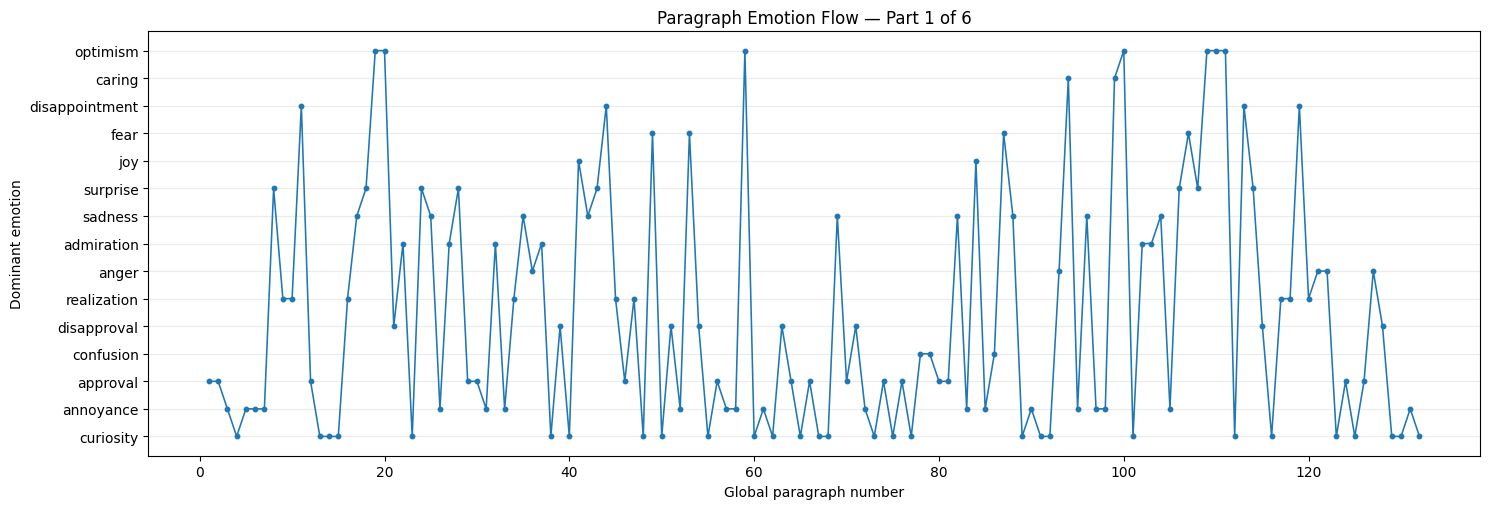

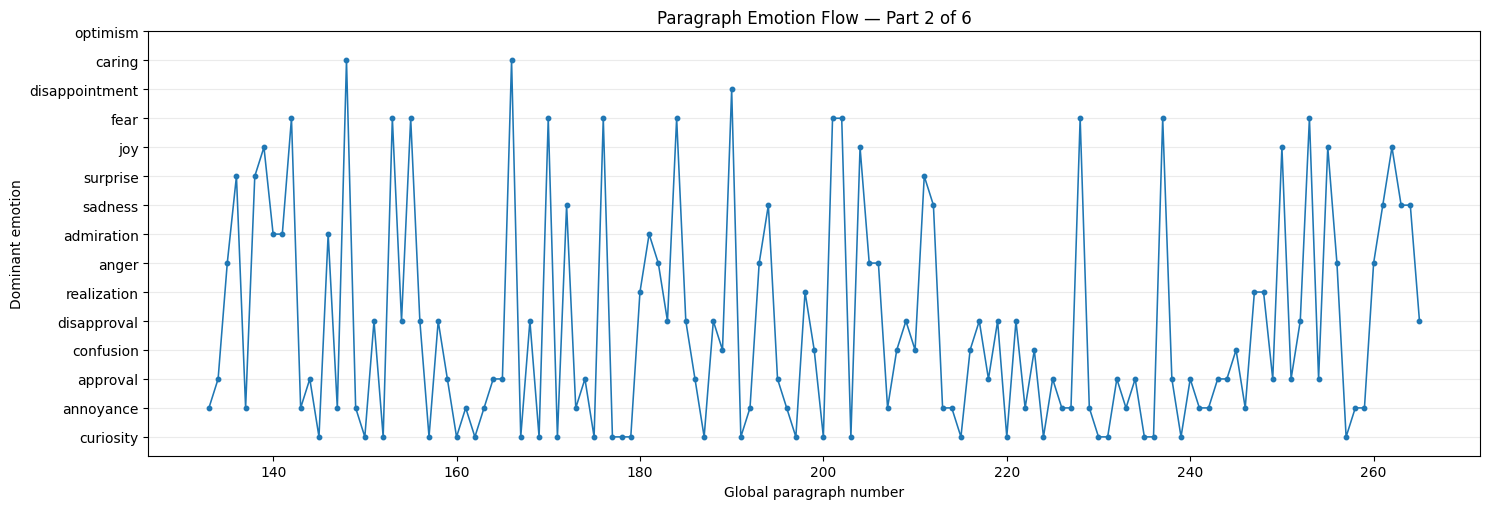

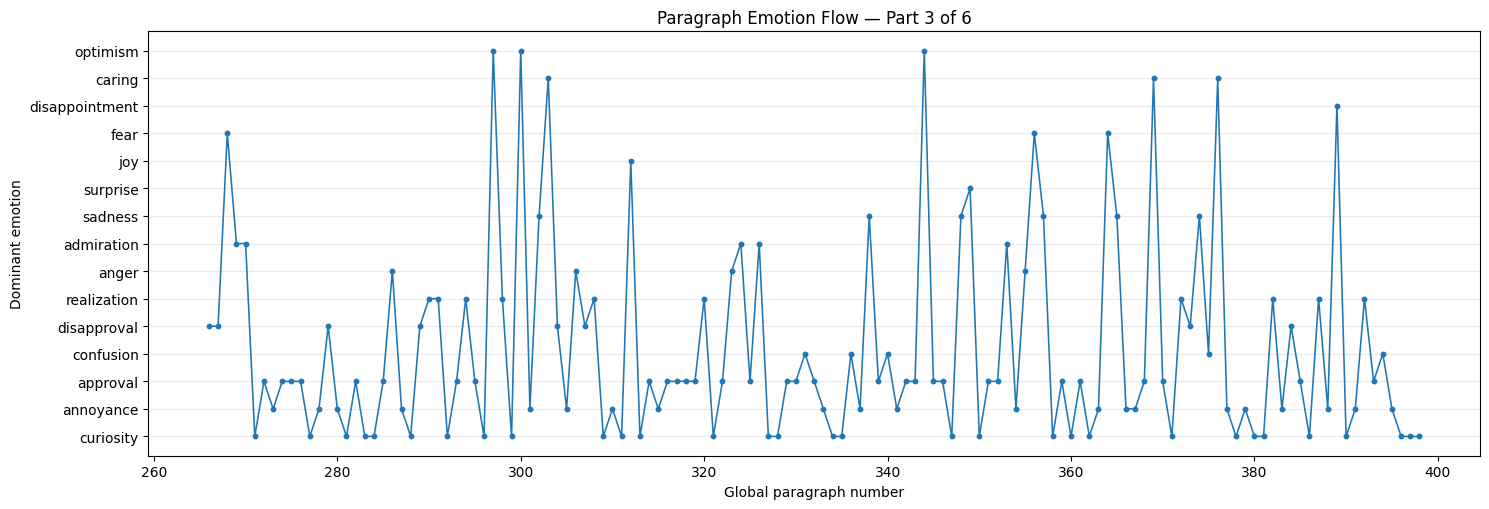

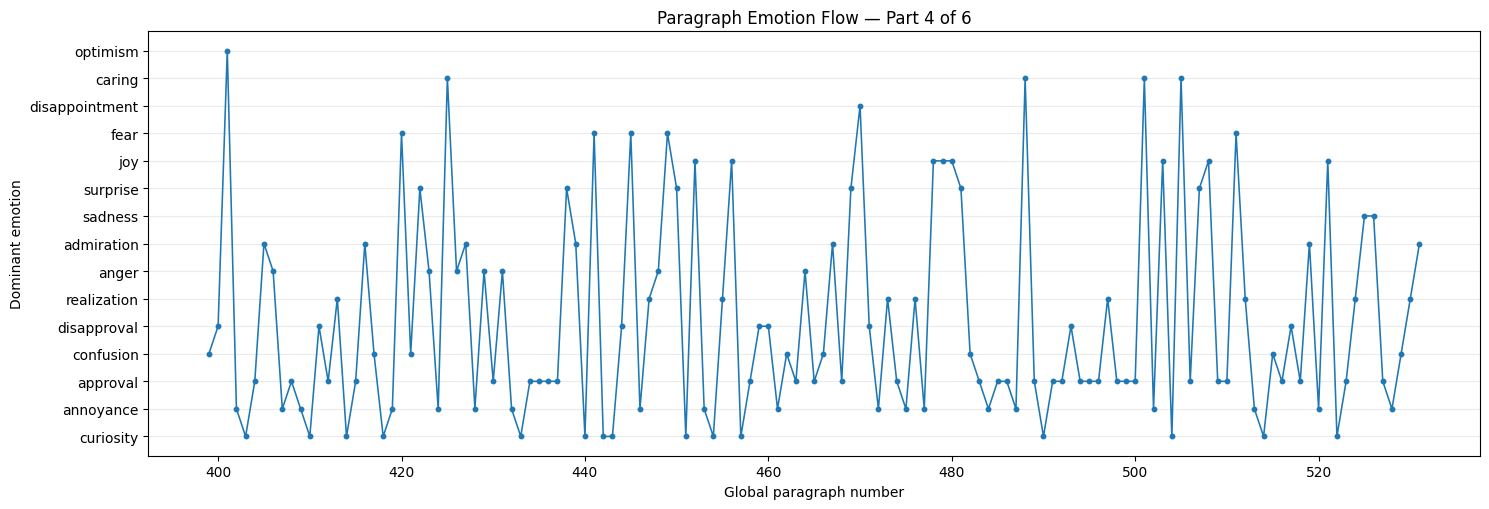

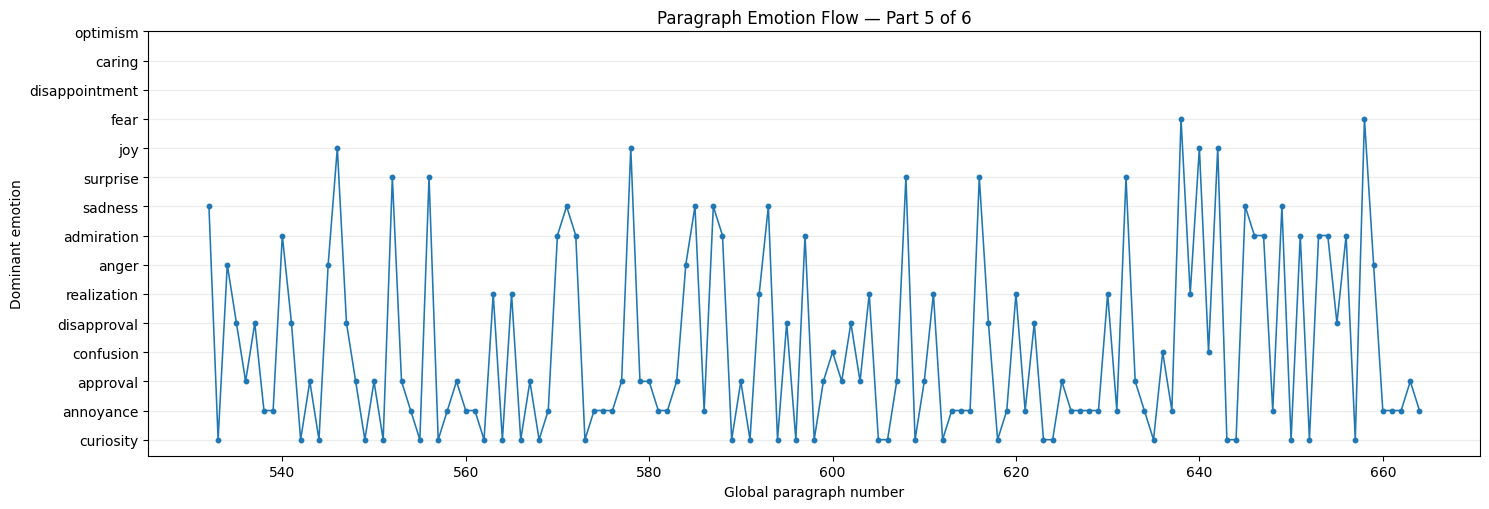

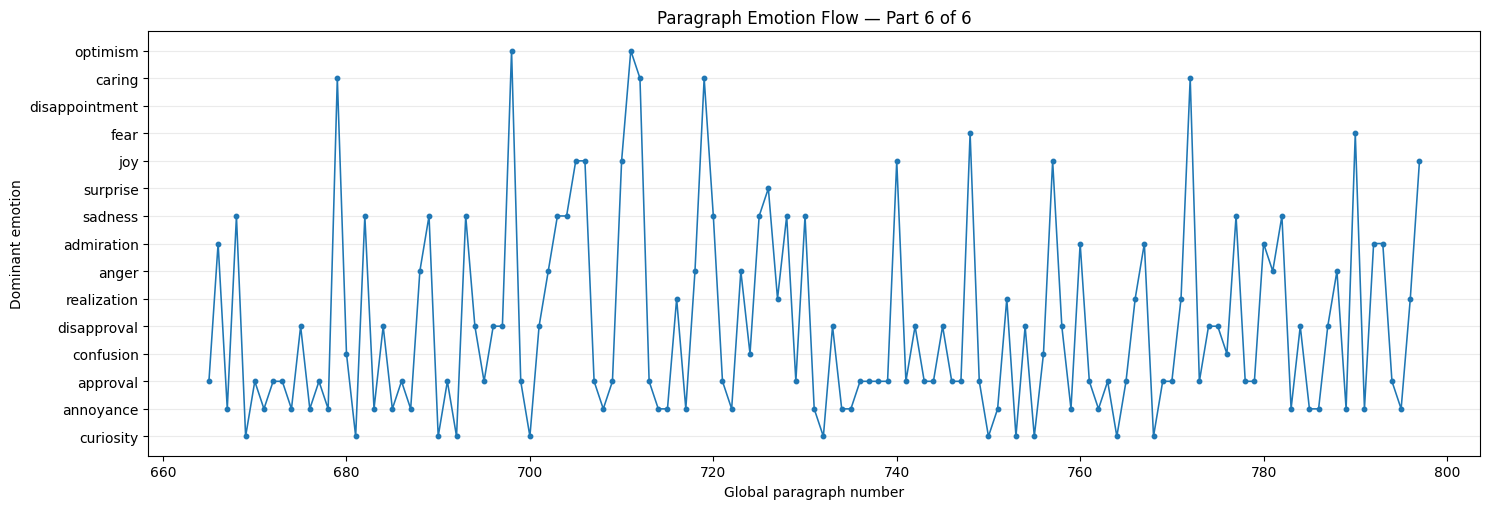

In [13]:
# ============================================================
# SECTION 1A — PARAGRAPH EMOTION FLOW — 6 PARTS
# ============================================================

n_parts = 6

# Divide the full book into 6 sequential parts
edges = np.linspace(
    0,
    len(paragraph_analysis),
    n_parts + 1
).astype(int)

# Fixed Y-axis order
emotion_y = {
    emotion: i
    for i, emotion in enumerate(TOP_15_EMOTIONS)
}

for part in range(n_parts):

    # Get paragraphs for this part
    part_df = paragraph_analysis.iloc[
        edges[part]:edges[part + 1]
    ].copy()

    # Correct check
    if part_df.empty:
        continue

    # Convert emotion label → Y-axis position
    part_df["emotion_y"] = (
        part_df["dominant_emotion"]
        .map(emotion_y)
    )

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(15, 5.2))

    plt.plot(
        part_df["global_paragraph_number"],
        part_df["emotion_y"],
        marker="o",
        markersize=3.2,
        linewidth=1.15
    )

    # --------------------------------------------------------
    # Y AXIS — 15 STRONGEST NON-NEUTRAL EMOTIONS
    # --------------------------------------------------------

    plt.yticks(
        range(len(TOP_15_EMOTIONS)),
        TOP_15_EMOTIONS
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel(
        "Global paragraph number"
    )

    plt.ylabel(
        "Dominant emotion"
    )

    plt.title(
        f"Paragraph Emotion Flow — "
        f"Part {part + 1} of {n_parts}"
    )

    # --------------------------------------------------------
    # GRID
    # --------------------------------------------------------

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()

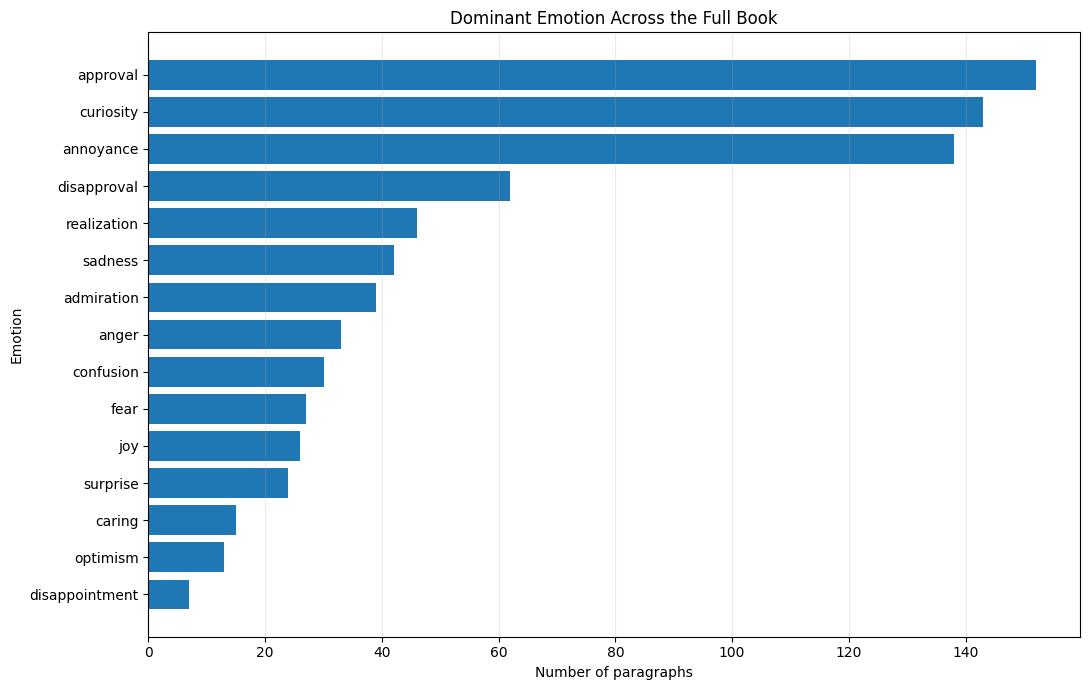

,emotion,paragraph_count,percentage
0,curiosity,143,17.942284
1,annoyance,138,17.314931
2,approval,152,19.071518
3,confusion,30,3.764115
4,disapproval,62,7.779172
5,realization,46,5.771644
6,anger,33,4.140527
7,admiration,39,4.893350
8,sadness,42,5.269762
9,surprise,24,3.011292


In [14]:

# ============================================================
# SECTION 1B — DOMINANT EMOTION ACROSS THE FULL BOOK
# ============================================================

dominant_counts = (
    paragraph_analysis["dominant_emotion"]
    .value_counts()
    .reindex(TOP_15_EMOTIONS, fill_value=0)
    .reset_index()
)

dominant_counts.columns = [
    "emotion",
    "paragraph_count"
]

dominant_counts["percentage"] = (
    dominant_counts["paragraph_count"]
    / len(paragraph_analysis)
    * 100
)

plot_df = dominant_counts[
    dominant_counts["paragraph_count"] > 0
].sort_values("paragraph_count")

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["emotion"],
    plot_df["paragraph_count"]
)

plt.xlabel("Number of paragraphs")
plt.ylabel("Emotion")
plt.title("Dominant Emotion Across the Full Book")

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

display(dominant_counts)



# SECTION 1C — SENTENCE-BY-SENTENCE EMOTION FLOW

The following plot collects sentences from **10 consecutive paragraphs**.
Each point is one sentence. Vertical lines mark paragraph boundaries.


Plot 1 paragraphs:
[46, 50, 74, 112, 277, 278, 302, 358, 362, 464, 507, 531, 539, 556, 571, 601, 634, 641, 757, 764]

Plot 2 paragraphs:
[2, 24, 42, 64, 109, 161, 263, 271, 416, 423, 508, 532, 537, 602, 608, 692, 705, 723, 740, 774]


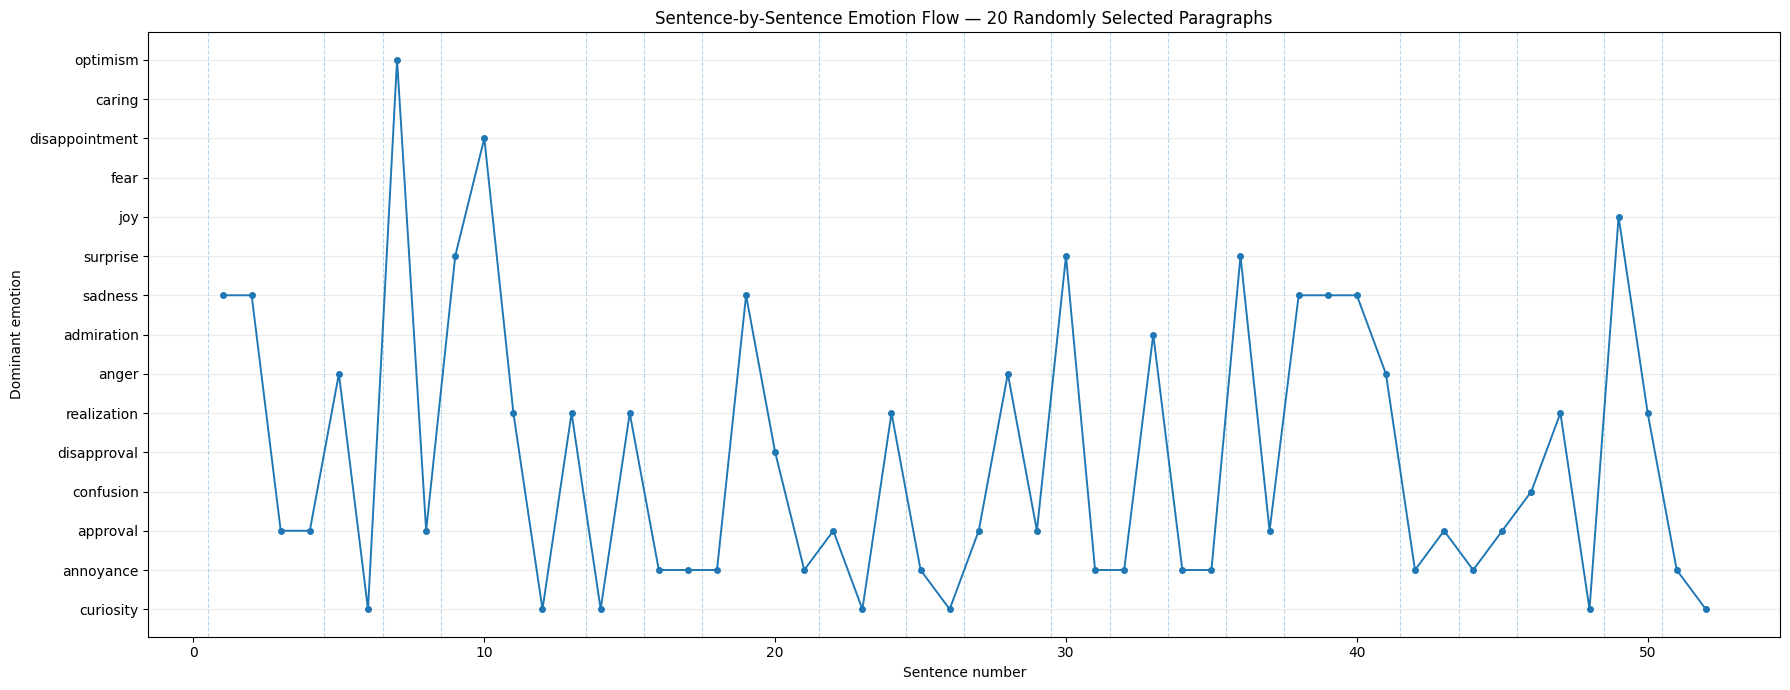

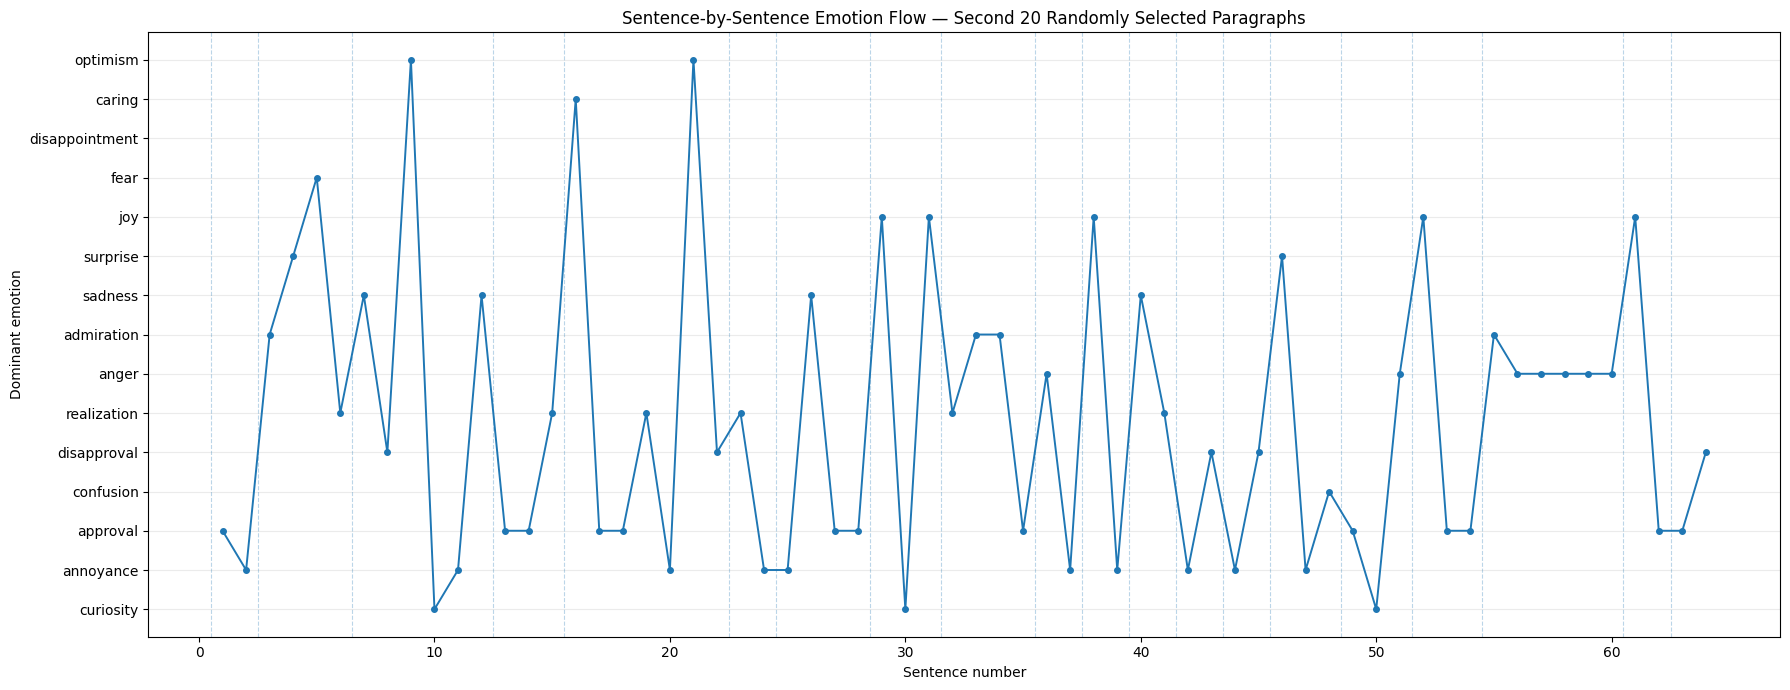


TWO SENTENCE-LEVEL EMOTION PLOTS

Plot 1: 52 sentences from 20 paragraphs
Plot 2: 64 sentences from a different 20 paragraphs


In [15]:
# ============================================================
# TWO SENTENCE → EMOTION PLOTS
# 20 PARAGRAPHS EACH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

RANDOM_SEED_1 = 42
RANDOM_SEED_2 = 100
N_PARAGRAPHS = 20


# ============================================================
# PREPARE SENTENCE DATA
# ============================================================

df = sentence_df.copy()

df = df.sort_values(
    ["global_paragraph_number"]
).reset_index(drop=True)

df["sentence_in_paragraph"] = (
    df.groupby("global_paragraph_number")
      .cumcount() + 1
)


# ============================================================
# FIND ELIGIBLE PARAGRAPHS
# ============================================================

paragraph_counts = (
    df.groupby("global_paragraph_number")
      .size()
)

eligible = paragraph_counts[
    paragraph_counts >= 2
].index.to_numpy()

if len(eligible) < 40:
    raise ValueError(
        f"Need at least 40 paragraphs, "
        f"but only {len(eligible)} are available."
    )


# ============================================================
# SELECT TWO DIFFERENT SETS OF 20 PARAGRAPHS
# ============================================================

rng1 = np.random.default_rng(RANDOM_SEED_1)

paragraphs_1 = rng1.choice(
    eligible,
    size=N_PARAGRAPHS,
    replace=False
)

# Remove first 20 before selecting second 20
remaining = np.setdiff1d(
    eligible,
    paragraphs_1
)

rng2 = np.random.default_rng(RANDOM_SEED_2)

paragraphs_2 = rng2.choice(
    remaining,
    size=N_PARAGRAPHS,
    replace=False
)

paragraphs_1 = np.sort(paragraphs_1)
paragraphs_2 = np.sort(paragraphs_2)


print("Plot 1 paragraphs:")
print(paragraphs_1.tolist())

print("\nPlot 2 paragraphs:")
print(paragraphs_2.tolist())


# ============================================================
# FUNCTION TO PREPARE SENTENCES
# ============================================================

def prepare_sentence_flow(
    paragraph_ids
):

    flow = df[
        df["global_paragraph_number"].isin(
            paragraph_ids
        )
    ].copy()

    flow = flow.sort_values(
        [
            "global_paragraph_number",
            "sentence_in_paragraph"
        ]
    ).reset_index(drop=True)

    flow["sentence_number"] = (
        np.arange(len(flow)) + 1
    )

    # Get dominant emotion
    emotion_columns = [
        "emotion_" + emotion
        for emotion in TOP_15_EMOTIONS
    ]

    flow["dominant_emotion"] = (
        flow[emotion_columns]
        .idxmax(axis=1)
        .str.replace(
            "emotion_",
            "",
            regex=False
        )
    )

    emotion_to_y = {
        emotion: i
        for i, emotion
        in enumerate(TOP_15_EMOTIONS)
    }

    flow["emotion_y"] = (
        flow["dominant_emotion"]
        .map(emotion_to_y)
    )

    return flow


flow1 = prepare_sentence_flow(
    paragraphs_1
)

flow2 = prepare_sentence_flow(
    paragraphs_2
)


# ============================================================
# PLOT 1
# 20 RANDOM PARAGRAPHS
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 7)
)

ax.plot(
    flow1["sentence_number"],
    flow1["emotion_y"],
    marker="o",
    markersize=4,
    linewidth=1.4
)

ax.set_yticks(
    range(len(TOP_15_EMOTIONS))
)

ax.set_yticklabels(
    TOP_15_EMOTIONS
)

ax.set_xlabel(
    "Sentence number"
)

ax.set_ylabel(
    "Dominant emotion"
)

ax.set_title(
    "Sentence-by-Sentence Emotion Flow — "
    "20 Randomly Selected Paragraphs"
)

# Paragraph boundaries
for p in paragraphs_1:

    rows = flow1[
        flow1["global_paragraph_number"] == p
    ]

    if rows.empty:
        continue

    start = rows["sentence_number"].iloc[0]

    ax.axvline(
        start - 0.5,
        linestyle="--",
        linewidth=0.8,
        alpha=0.3
    )

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2
# DIFFERENT 20 RANDOM PARAGRAPHS
# ============================================================

fig, ax = plt.subplots(
    figsize=(18, 7)
)

ax.plot(
    flow2["sentence_number"],
    flow2["emotion_y"],
    marker="o",
    markersize=4,
    linewidth=1.4
)

ax.set_yticks(
    range(len(TOP_15_EMOTIONS))
)

ax.set_yticklabels(
    TOP_15_EMOTIONS
)

ax.set_xlabel(
    "Sentence number"
)

ax.set_ylabel(
    "Dominant emotion"
)

ax.set_title(
    "Sentence-by-Sentence Emotion Flow — "
    "Second 20 Randomly Selected Paragraphs"
)

# Paragraph boundaries
for p in paragraphs_2:

    rows = flow2[
        flow2["global_paragraph_number"] == p
    ]

    if rows.empty:
        continue

    start = rows["sentence_number"].iloc[0]

    ax.axvline(
        start - 0.5,
        linestyle="--",
        linewidth=0.8,
        alpha=0.3
    )

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("TWO SENTENCE-LEVEL EMOTION PLOTS")
print("=" * 60)

print(
    "\nPlot 1:",
    len(flow1),
    "sentences from 20 paragraphs"
)

print(
    "Plot 2:",
    len(flow2),
    "sentences from a different 20 paragraphs"
)


# SECTION 2 — ENVIRONMENTAL TOPIC FLOW

The analysis focuses only on observable environmental/context topics occurring
paragraph by paragraph.

Categories:
- Nature / Landscape
- Built / Indoor
- Weather / Atmosphere
- Social Environment
- Time / Season
- Movement / Travel

A paragraph may contain more than one category. The flow plot uses the category
with the strongest lexical presence. Paragraphs with no detected context are
left blank in the flow plot.


In [16]:

# ============================================================
# SECTION 2A — ENVIRONMENT DETECTION
# ============================================================

ENV_LEXICONS = {
    "Nature / Landscape": [
        "forest","woods","wood","tree","trees","garden","field","fields",
        "meadow","park","grove","hill","hills","mountain","valley","river",
        "stream","lake","pond","sea","ocean","shore","coast","beach",
        "landscape","countryside","woodland"
    ],
    "Built / Indoor": [
        "house","home","room","rooms","hall","door","window","stairs",
        "bedroom","parlour","parlor","library","dining-room","dining room",
        "kitchen","office","building","castle","mansion","estate","church",
        "chapel","inn","hotel","street","road","lane","square","town",
        "village","city"
    ],
    "Weather / Atmosphere": [
        "rain","rainy","raining","storm","stormy","thunder","lightning",
        "wind","windy","snow","snowing","fog","foggy","mist","misty",
        "cloud","clouds","cloudy","sun","sunlight","sunshine","dark",
        "darkness","cold","warm","heat","weather","frost","frozen"
    ],
    "Social Environment": [
        "family","mother","father","brother","sister","husband","wife",
        "daughter","son","parent","parents","friend","friends","guest",
        "guests","party","ball","dance","dinner","breakfast","conversation",
        "meeting","visit","letter","company","crowd","society","community",
        "marriage","married","courtship"
    ],
    "Time / Season": [
        "morning","afternoon","evening","night","midnight","dawn","daybreak",
        "day","week","weeks","month","months","year","years","today",
        "yesterday","tomorrow","spring","summer","autumn","fall","winter",
        "season","hour","hours","later","soon","before","after","early","late"
    ],
    "Movement / Travel": [
        "walk","walked","walking","run","ran","running","ride","rode","riding",
        "travel","travelled","traveled","journey","journeyed","go","went",
        "going","come","came","coming","return","returned","returning","leave",
        "left","leaving","enter","entered","entering","arrive","arrived",
        "arriving","depart","departed","cross","crossed","visit","visited",
        "stay","stayed","move","moved"
    ]
}

ENV_ORDER = list(ENV_LEXICONS.keys())

def find_terms(text, terms):
    text = str(text).lower()
    return [
        term for term in terms
        if re.search(
            r"\b" + re.escape(term) + r"\b",
            text
        )
    ]

for category, terms in ENV_LEXICONS.items():

    paragraph_analysis[category] = (
        paragraph_analysis["paragraph_text"]
        .apply(
            lambda text, t=terms:
            find_terms(text, t)
        )
    )

    paragraph_analysis[
        f"{category}__count"
    ] = paragraph_analysis[category].apply(len)

def dominant_environment(row):

    counts = {
        category: int(
            row[f"{category}__count"]
        )
        for category in ENV_ORDER
    }

    maximum = max(counts.values())

    if maximum == 0:
        return np.nan

    # Stable tie-break based on ENV_ORDER
    for category in ENV_ORDER:
        if counts[category] == maximum:
            return category

paragraph_analysis["dominant_environment"] = (
    paragraph_analysis.apply(
        dominant_environment,
        axis=1
    )
)

print("Environmental categories:")
for category in ENV_ORDER:
    print("-", category)


Environmental categories:
- Nature / Landscape
- Built / Indoor
- Weather / Atmosphere
- Social Environment
- Time / Season
- Movement / Travel


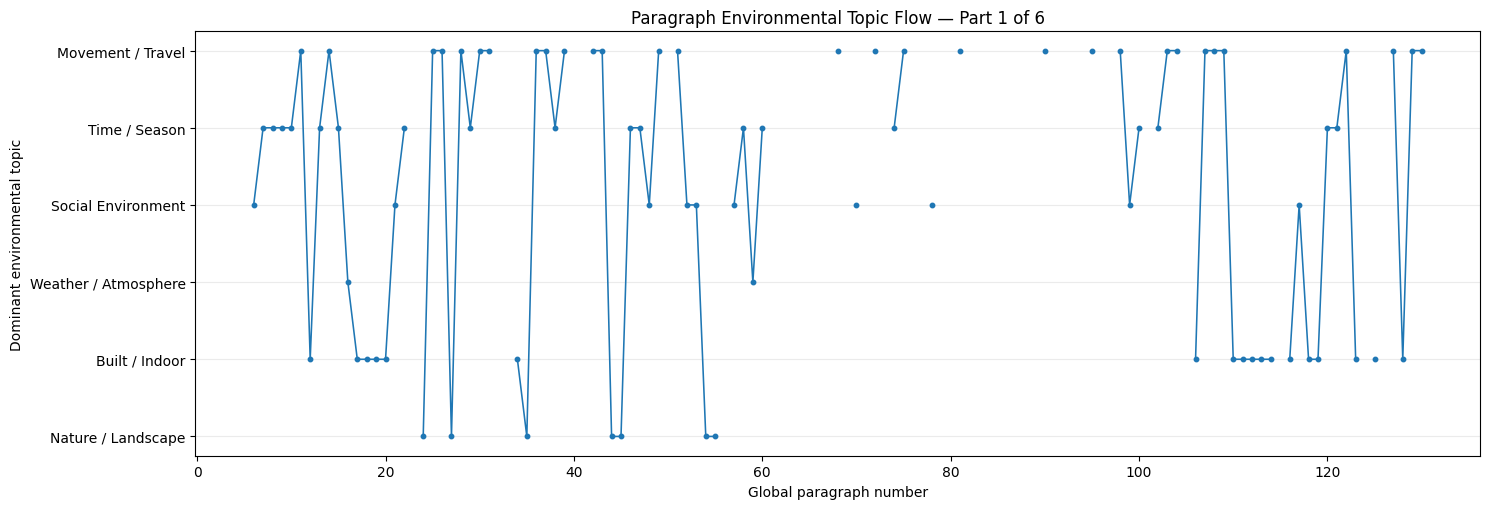

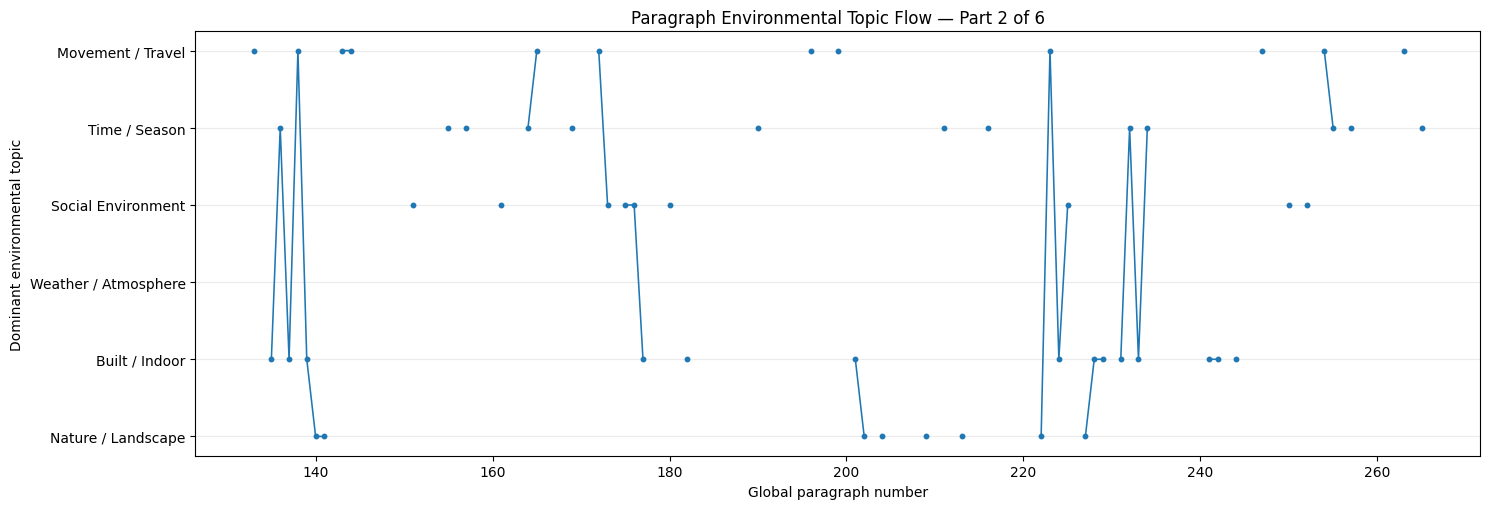

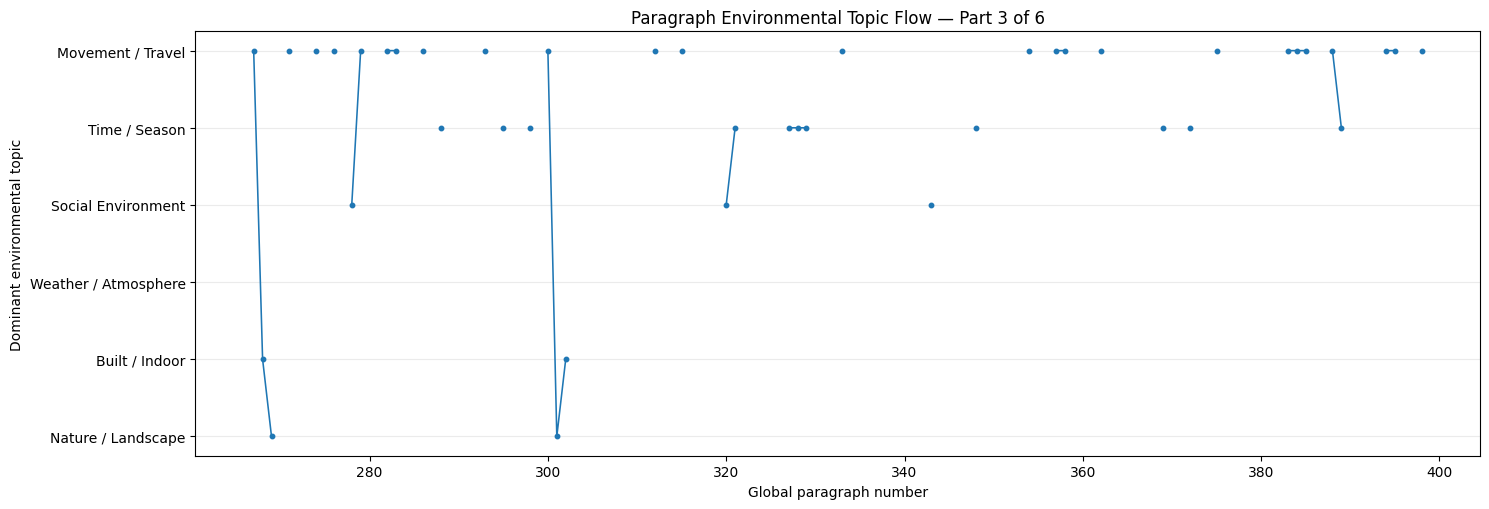

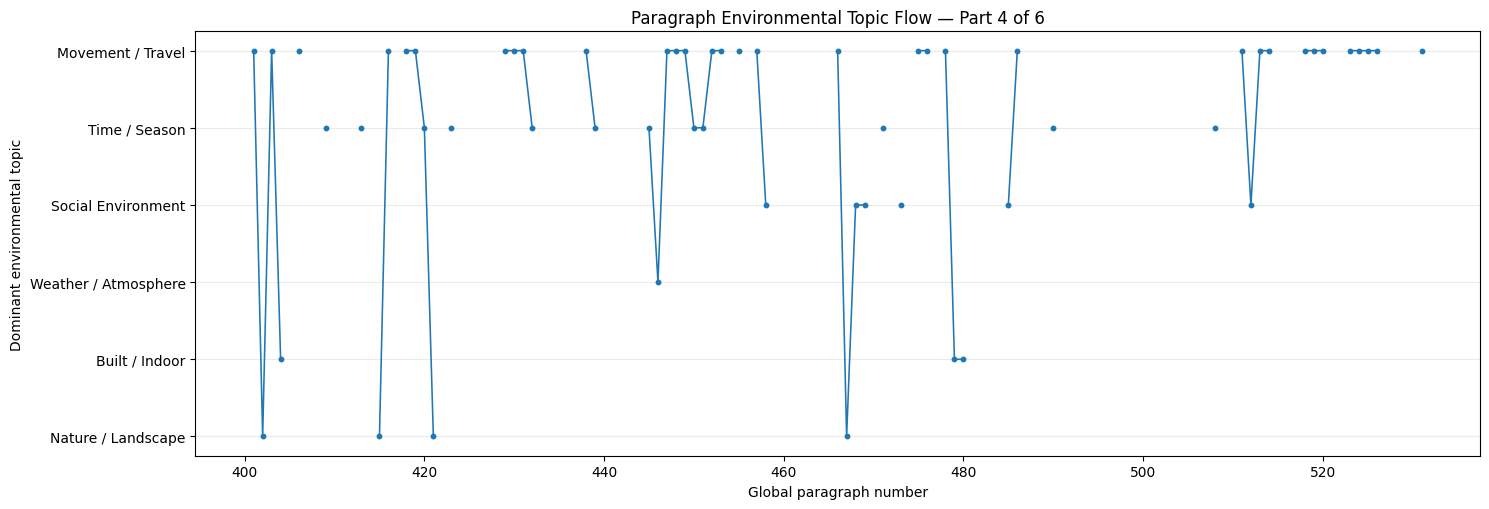

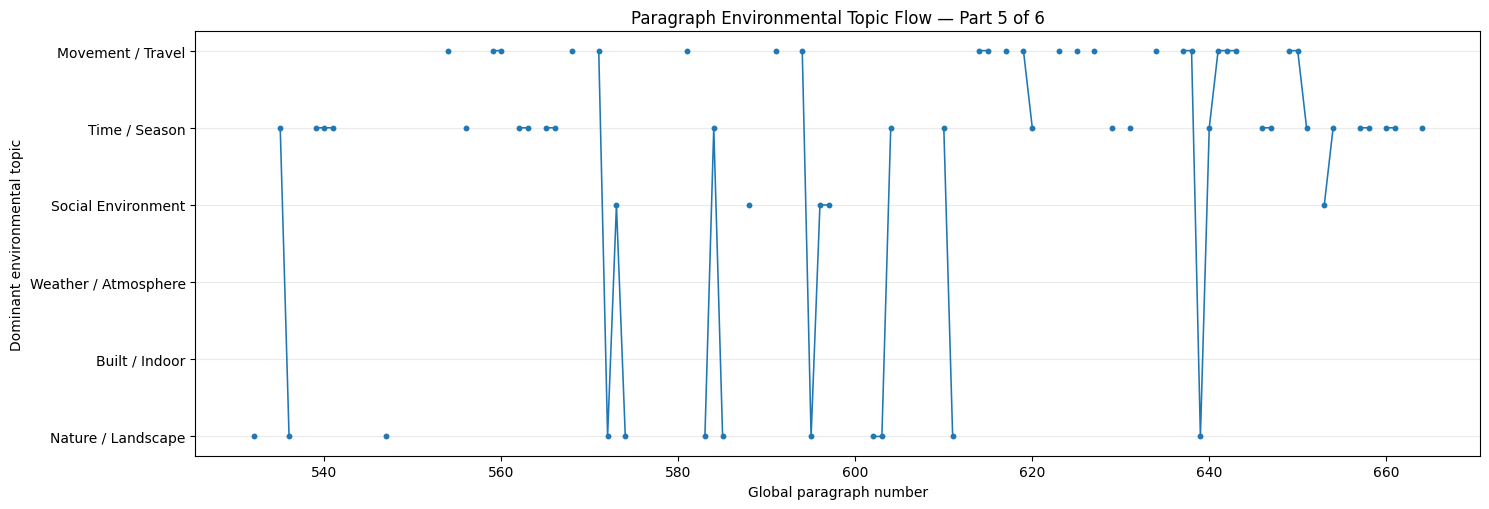

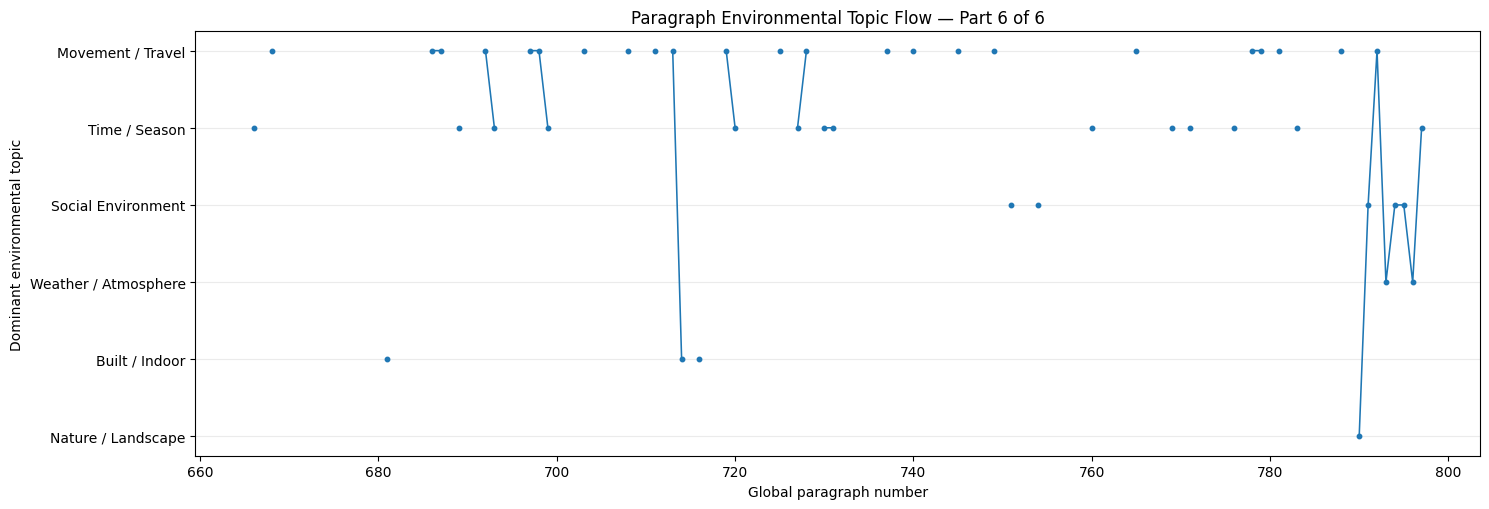

In [17]:
# ============================================================
# SECTION 2B — ENVIRONMENTAL TOPIC FLOW — 6 PARTS
# ============================================================

environment_y = {
    category: i
    for i, category in enumerate(ENV_ORDER)
}

for part in range(n_parts):

    # Get the paragraphs belonging to this part
    part_df = paragraph_analysis.iloc[
        edges[part]:edges[part + 1]
    ].copy()

    # IMPORTANT:
    # part = integer (0, 1, 2, ...)
    # part_df = DataFrame
    if part_df.empty:
        continue

    # --------------------------------------------------------
    # Map environmental topic → Y-axis position
    # --------------------------------------------------------

    part_df["environment_y"] = (
        part_df["dominant_environment"]
        .map(environment_y)
    )

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(figsize=(15, 5.2))

    plt.plot(
        part_df["global_paragraph_number"],
        part_df["environment_y"],
        marker="o",
        markersize=3.2,
        linewidth=1.15
    )

    # --------------------------------------------------------
    # Y AXIS
    # --------------------------------------------------------

    plt.yticks(
        range(len(ENV_ORDER)),
        ENV_ORDER
    )

    # --------------------------------------------------------
    # LABELS
    # --------------------------------------------------------

    plt.xlabel(
        "Global paragraph number"
    )

    plt.ylabel(
        "Dominant environmental topic"
    )

    plt.title(
        f"Paragraph Environmental Topic Flow — "
        f"Part {part + 1} of {n_parts}"
    )

    # --------------------------------------------------------
    # GRID
    # --------------------------------------------------------

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()

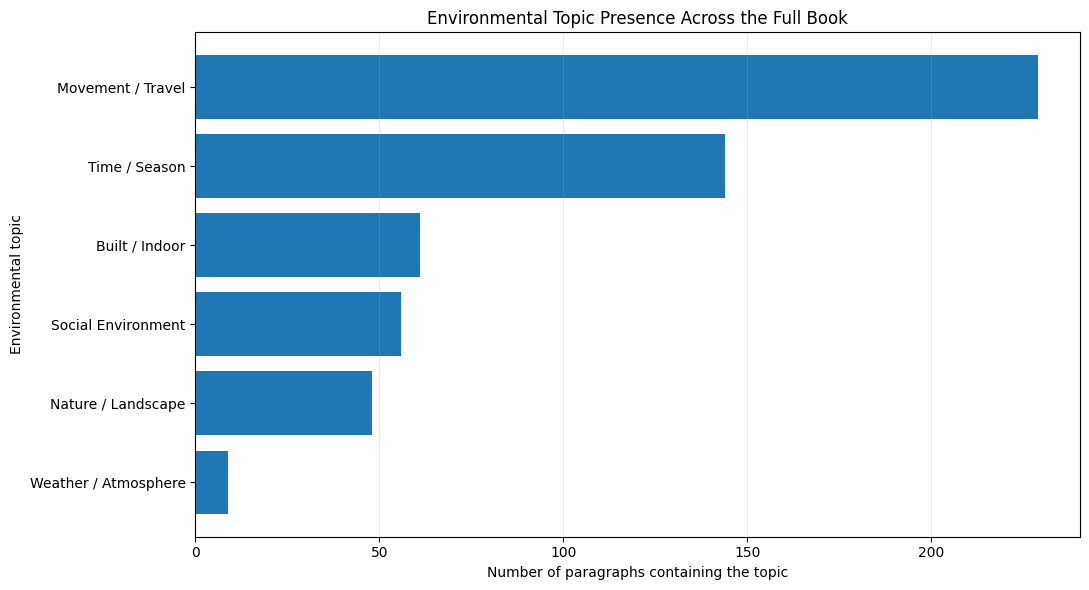

,environment_topic,paragraphs_with_topic,percentage
5,Movement / Travel,229,28.732748
4,Time / Season,144,18.067754
1,Built / Indoor,61,7.653701
3,Social Environment,56,7.026349
0,Nature / Landscape,48,6.022585
2,Weather / Atmosphere,9,1.129235


In [18]:

# ============================================================
# SECTION 2C — OVERALL ENVIRONMENTAL TOPIC PRESENCE
# ============================================================

environment_presence = pd.DataFrame({
    "environment_topic": ENV_ORDER,
    "paragraphs_with_topic": [
        int(
            paragraph_analysis[category]
            .apply(lambda x: len(x) > 0)
            .sum()
        )
        for category in ENV_ORDER
    ]
})

environment_presence["percentage"] = (
    environment_presence["paragraphs_with_topic"]
    / len(paragraph_analysis)
    * 100
)

environment_presence = environment_presence.sort_values(
    "paragraphs_with_topic",
    ascending=True
)

plt.figure(figsize=(11, 6))

plt.barh(
    environment_presence["environment_topic"],
    environment_presence["paragraphs_with_topic"]
)

plt.xlabel(
    "Number of paragraphs containing the topic"
)

plt.ylabel("Environmental topic")

plt.title(
    "Environmental Topic Presence Across the Full Book"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

display(
    environment_presence.sort_values(
        "paragraphs_with_topic",
        ascending=False
    )
)
